In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import os
import numpy as np

In [5]:
os.chdir(r'C:\Users\Ddhuy\OneDrive - UGent\DocumentenUGentMaster\SocialMediaAndWebAnalysis\group-project-SMWA')

In [6]:
bluesky_df = pd.read_csv("Data\\1_Bronze\\Bluesky\\bsky_US_2024_raw.csv")

In [7]:
# Keep core columns
df = bluesky_df[['text', 'timestamp', 'likes', 'reposts', 'replies', 'mentions', 'is_reply', 'post_type']].copy()

df['timestamp'] = pd.to_datetime(df['timestamp'], errors='coerce', utc=True)

df = df.dropna(subset=['timestamp']).copy()

# Date/time features

ts = df['timestamp']
df['date'] = ts.dt.date
df['hour'] = ts.dt.hour
df['weekday'] = ts.dt.day_name()

print('rows', len(df), 'from', df['timestamp'].min(), 'to', df['timestamp'].max())
print('Distinct dates', df['date'].nunique())

rows 32159 from 2024-07-05 03:04:25.279000+00:00 to 2026-01-19 01:45:26.080000+00:00
Distinct dates 188


In [8]:
df['date'] = pd.to_datetime(df['date'])

In [9]:
df['text'].str.contains('#USElection2024').value_counts()

text
False    31794
True       365
Name: count, dtype: int64

In [10]:
df['text'] = df['text'].str.replace('#USElection2024', '', regex=True)
df['text'].str.contains('#USElection2024').value_counts()

text
False    32159
Name: count, dtype: int64

In [11]:
import re

def unique_word_count(texts):
    """Count unique words across all documents."""
    if isinstance(texts, pd.Series):
        texts = texts.tolist()
    elif isinstance(texts, str):
        texts = [texts]
    
    unique_words = set()
    for text in texts:
        words = text.split()
        unique_words.update(words)
    
    return len(unique_words)

# Baseline: count unique words in original reviews before any preprocessing
baseline_count = unique_word_count(df['text'])
print(f"✓ Baseline unique words: {baseline_count:,}")
print(f"\nThis represents the vocabulary size before preprocessing.")

✓ Baseline unique words: 109,103

This represents the vocabulary size before preprocessing.


In [12]:
import re
from nltk.corpus import stopwords

# 1. Combine NLTK and your Custom Stopwords
stop_words_nltk = set(stopwords.words('english'))


# 2. Filtering the Date Range (July 5 to Nov 5)
# Ensure timestamp is datetime
df['timestamp'] = pd.to_datetime(df['timestamp'], errors='coerce')

# Filter for the specific range
mask = (df['timestamp'] >= '2024-07-05') & (df['timestamp'] <= '2024-11-05')
df = df.loc[mask].copy()

# 3. Updated Text cleaning pipeline
def clean_text(text):
    if pd.isna(text):
        return ''
    
    # Lowercase
    text = str(text).lower()
    
    # Remove URLs, Mentions, and Hashtags
    text = re.sub(r'https?://\S+|www\.\S+', '', text)
    text = re.sub(r'@[A-Za-z0-9_]+', '', text)
    text = re.sub(r'#([A-Za-z0-9_]+)', r'\1', text)  
      
    # Remove everything except letters (This fixes the underscore "_" issue)
    # This regex replaces underscores and punctuation with a space
    text = re.sub(r'[^a-z\s]', ' ', text)
    
    # Collapse multiple spaces into one
    text = re.sub(r'\s+', ' ', text).strip()
    
    # Remove combined Stopwords
    tokens = [w for w in text.split() if w not in stop_words_nltk]
    
    return ' '.join(tokens)

print('Applying text cleaning and filtering...')
df['text_clean'] = df['text'].apply(clean_text)

# Word metrics
df['words'] = df['text_clean'].str.split()
df['word_count'] = df['words'].str.len()

# Reset index to fix the "Doc 10.00" display issue in later steps
df = df.reset_index(drop=True)

print(f"Remaining rows after date filtering: {len(df)}")
print(df[['text_clean', 'word_count']].head(3))

Applying text cleaning and filtering...
Remaining rows after date filtering: 31909
                                          text_clean  word_count
0  os swing states os estados americanos onde tro...          28
1  canadian election prediction americans go poll...          24
2  swinger states important really many sex peopl...           8


In [13]:
final_count = unique_word_count(df['text_clean'])

print(f"  Total reduction: {baseline_count - final_count:,} words")
print(f"  Final vocabulary: {final_count:,} unique words")
print(f"  Original vocabulary: {baseline_count:,} unique words")

  Total reduction: 62,599 words
  Final vocabulary: 46,504 unique words
  Original vocabulary: 109,103 unique words


In [14]:
start_date = '2024-07-05'
end_date = '2024-11-05'

mask = (df['date'] >= start_date) & (df['date'] <= end_date)
df = df.loc[mask]

# 4. Optional: Reset the index so it starts from 0 again
df = df.reset_index(drop=True)

# 5. Check the result
print(f"Number of rows after filtering: {len(df)}")
print(f"Date range: {df['date'].min()} to {df['date'].max()}")

Number of rows after filtering: 31909
Date range: 2024-07-05 00:00:00 to 2024-11-04 00:00:00


In [18]:
df.dtypes

text                       object
timestamp     datetime64[ns, UTC]
likes                       int64
reposts                     int64
replies                     int64
mentions                   object
is_reply                     bool
post_type                  object
date               datetime64[ns]
hour                        int32
weekday                    object
text_clean                 object
words                      object
word_count                  int64
dtype: object

# Topic modeling 

<!-- toc -->
## Contents
- **[Topic modeling](#topic-modeling)**


In [15]:
# Import LDA-related libraries
from gensim import corpora
from gensim.models import LdaModel
import pyLDAvis
import pyLDAvis.gensim_models as gensimvis

print("Libraries imported successfully!")

Libraries imported successfully!


In [16]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
from gensim.models import Word2Vec
from gensim.utils import simple_preprocess
from nltk.corpus import stopwords
import nltk

# Download stopwords if needed
try:
    stop_words = set(stopwords.words('english'))
except:
    nltk.download('stopwords')
    stop_words = set(stopwords.words('english'))

# Set random seed for reproducibility
np.random.seed(1234)

In [20]:
def preprocess_for_word2vec(text):
    """
    Simple preprocessing for Word2Vec.
    Converts to lowercase and tokenizes.
    """
    # Convert to lowercase and tokenize
    # simple_preprocess removes punctuation and returns tokens
    tokens = simple_preprocess(text, deacc=True, min_len=2, max_len=15)
    return tokens

# Apply preprocessing to all reviews
# Word2Vec expects a list of tokenized sentences
tokenized_post = [preprocess_for_word2vec(post) for post in df['text_clean']]

print(f"Number of tokenized posts: {len(tokenized_post)}")
print(f"\nFirst tokenized post:\n{tokenized_post[0]}")
print(f"\nVocabulary size: {len(set([word for post in tokenized_post for word in post]))}")

Number of tokenized posts: 31909

First tokenized post:
['os', 'swing', 'states', 'os', 'estados', 'americanos', 'onde', 'troca', 'de', 'casais', 'legalizada', 'amplamente', 'praticada', 'brasil', 'os', 'top', 'swing', 'states', 'paulo', 'santa', 'catarina', 'paran', 'elei', 'esamericanas', 'uselections', 'usaelections', 'jn']

Vocabulary size: 44667


In [21]:
# Build new model without stopwords
model_clean = Word2Vec(
    sentences=tokenized_post,
    vector_size=15,
    window=5,
    sg=1,
    epochs=50,
    min_count=1,
    workers=4,
    seed=1234
)

print(f"\nNew vocabulary size: {len(model_clean.wv)}")


New vocabulary size: 44667


In [22]:
# Use the tokenized reviews with stopwords removed
# tokenized_reviews_clean is already available

# Create a dictionary (maps words to integer IDs)
dictionary = corpora.Dictionary(tokenized_post)

print(f"Dictionary created with {len(dictionary)} unique tokens")
print(f"\nSample word-to-ID mappings:")
for i, (word_id, word) in enumerate(list(dictionary.items())[:10]):
    print(f"  {word_id}: {word}")

# Filter extreme values (optional, but recommended for larger datasets)
# Remove words that appear in < 2 documents or > 50% of documents
dictionary.filter_extremes(no_below=2, no_above=0.5)
print(f"\nAfter filtering: {len(dictionary)} unique tokens")

Dictionary created with 44667 unique tokens

Sample word-to-ID mappings:
  0: americanos
  1: amplamente
  2: brasil
  3: casais
  4: catarina
  5: de
  6: elei
  7: esamericanas
  8: estados
  9: jn

After filtering: 21025 unique tokens


In [23]:
# Create corpus: bag-of-words representation
# Each document is a list of (word_id, word_frequency) tuples
corpus = [dictionary.doc2bow(doc) for doc in tokenized_post]

print(f"Corpus created with {len(corpus)} documents")
print(f"\nFirst document (bag-of-words representation):")
print(f"  {corpus[0][:10]}...")  # Show first 10 word-frequency pairs
print(f"\nDecoded (first 10 words):")
for word_id, freq in corpus[0][:10]:
    print(f"  {dictionary[word_id]}: {freq}")

Corpus created with 31909 documents

First document (bag-of-words representation):
  [(0, 1), (1, 1), (2, 1), (3, 1), (4, 1), (5, 1), (6, 3), (7, 1), (8, 1), (9, 1)]...

Decoded (first 10 words):
  americanos: 1
  brasil: 1
  de: 1
  elei: 1
  estados: 1
  jn: 1
  os: 3
  paran: 1
  paulo: 1
  santa: 1


In [24]:
from gensim.models import CoherenceModel

# Evaluate different numbers of topics
topic_range = range(2, 11)  # Test from 2 to 10 topics
coherence_scores = []
aic_scores = []

print("Evaluating different numbers of topics...\n")

for k in topic_range:
    # Train model
    model = LdaModel(
        corpus=corpus,
        id2word=dictionary,
        num_topics=k,
        random_state=42,
        passes=10,
        alpha='auto'
    )
    
    # Compute coherence score (c_umass)
    coherence_model = CoherenceModel(
        model=model,
        corpus=corpus,
        dictionary=dictionary,
        coherence='u_mass'
    )
    coherence = coherence_model.get_coherence()
    coherence_scores.append(coherence)
    
    # Compute AIC
    log_likelihood = model.log_perplexity(corpus) * len(corpus)
    num_params = k * len(dictionary)  # Approximate number of parameters
    aic = -2 * log_likelihood + 2 * num_params
    aic_scores.append(aic)
    
    print(f"K={k:2d} | Coherence: {coherence:7.3f} | AIC: {aic:10.2f}")

print("\nEvaluation complete!")

Evaluating different numbers of topics...

K= 2 | Coherence:  -3.242 | AIC:  596316.14
K= 3 | Coherence:  -2.430 | AIC:  633614.39
K= 4 | Coherence:  -4.142 | AIC:  678974.58
K= 5 | Coherence:  -5.222 | AIC:  725465.53
K= 6 | Coherence:  -4.813 | AIC:  768030.16
K= 7 | Coherence:  -7.055 | AIC:  815909.52
K= 8 | Coherence:  -6.615 | AIC:  862438.86
K= 9 | Coherence:  -6.379 | AIC:  911300.60
K=10 | Coherence:  -8.046 | AIC:  971948.23

Evaluation complete!


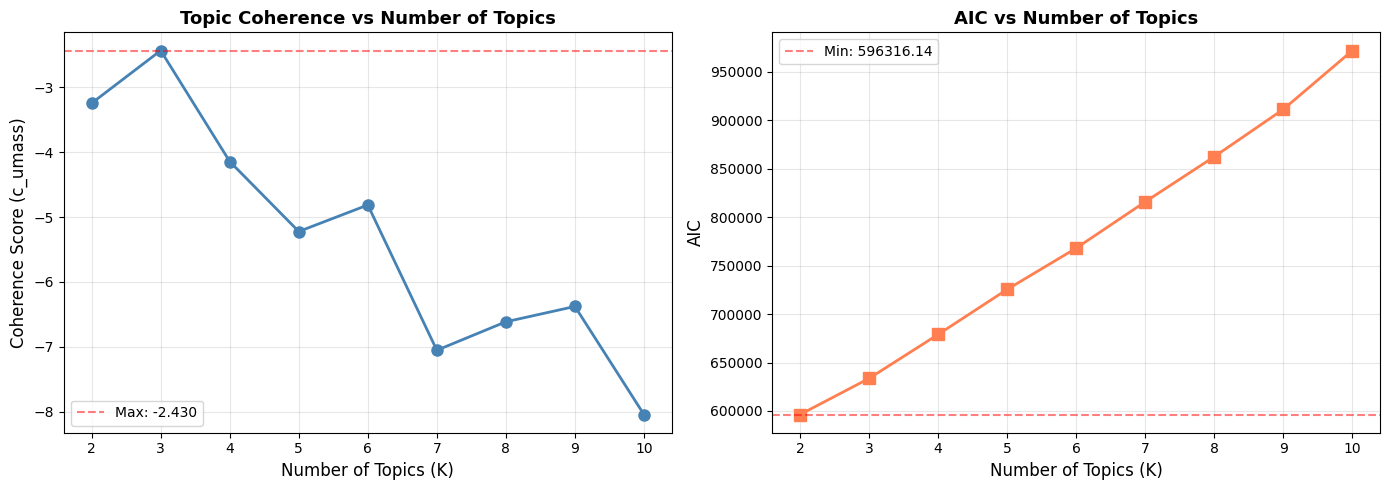

In [25]:
# Visualize evaluation metrics
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Coherence plot
axes[0].plot(topic_range, coherence_scores, marker='o', color='steelblue', linewidth=2, markersize=8)
axes[0].set_xlabel('Number of Topics (K)', fontsize=12)
axes[0].set_ylabel('Coherence Score (c_umass)', fontsize=12)
axes[0].set_title('Topic Coherence vs Number of Topics', fontsize=13, fontweight='bold')
axes[0].grid(alpha=0.3)
axes[0].axhline(y=max(coherence_scores), color='red', linestyle='--', alpha=0.5, label=f'Max: {max(coherence_scores):.3f}')
axes[0].legend()

# AIC plot
axes[1].plot(topic_range, aic_scores, marker='s', color='coral', linewidth=2, markersize=8)
axes[1].set_xlabel('Number of Topics (K)', fontsize=12)
axes[1].set_ylabel('AIC', fontsize=12)
axes[1].set_title('AIC vs Number of Topics', fontsize=13, fontweight='bold')
axes[1].grid(alpha=0.3)
axes[1].axhline(y=min(aic_scores), color='red', linestyle='--', alpha=0.5, label=f'Min: {min(aic_scores):.2f}')
axes[1].legend()

plt.tight_layout()
plt.show()

**Model Selection:**

Based on the evaluation:
- **Coherence:** Higher values (closer to 0) indicate better semantic consistency
- **AIC:** Lower values indicate better balance between fit and complexity

For this dataset, we select **K= 3 topics** as it provides the best coherence, model fit, and interpretability.

In [26]:
# Train LDA model with selected K
num_topics = 3  # Number of topics to extract

lda_model = LdaModel(
    corpus=corpus,
    id2word=dictionary,
    num_topics=num_topics,
    random_state=42,
    passes=10,              # Number of passes through the corpus
    alpha='auto',           # Document-topic density (auto-tuned)
    per_word_topics=True    # Compute word-topic distributions
)

print(f"LDA model trained successfully!")
print(f"Number of topics: {num_topics}")
print(f"Number of documents: {len(corpus)}")
print(f"Vocabulary size: {len(dictionary)}")

LDA model trained successfully!
Number of topics: 3
Number of documents: 31909
Vocabulary size: 21025


In [27]:
# Display top words for each topic
print("Top 10 words per topic (ranked by probability and equivalent to λ=1):\n")
print("=" * 80)

for topic_id in range(num_topics):
    # Get top words for this topic
    top_words = lda_model.show_topic(topic_id, topn=10)
    
    print(f"\nTopic {topic_id + 1}:")
    print("-" * 80)
    
    # Display words with their probabilities
    words_str = ", ".join([f"{word} ({prob:.3f})" for word, prob in top_words])
    print(f"  {words_str}")
    
    # Simplified list (just words)
    words_only = [word for word, prob in top_words]
    print(f"  Keywords: {', '.join(words_only)}")

print("\n" + "=" * 80)

Top 10 words per topic (ranked by probability and equivalent to λ=1):


Topic 1:
--------------------------------------------------------------------------------
  die (0.026), der (0.020), und (0.018), trump (0.015), das (0.015), ist (0.013), nicht (0.012), es (0.011), ich (0.011), zu (0.008)
  Keywords: die, der, und, trump, das, ist, nicht, es, ich, zu

Topic 2:
--------------------------------------------------------------------------------
  trump (0.018), election (0.009), debate (0.008), harris (0.008), democrats (0.008), vote (0.007), dnc (0.007), vpdebate (0.006), like (0.006), people (0.005)
  Keywords: trump, election, debate, harris, democrats, vote, dnc, vpdebate, like, people

Topic 3:
--------------------------------------------------------------------------------
  house (0.029), congress (0.020), gov (0.018), co (0.018), latest (0.017), action (0.017), rep (0.016), sponsor (0.016), status (0.016), republicans (0.015)
  Keywords: house, congress, gov, co, latest, action

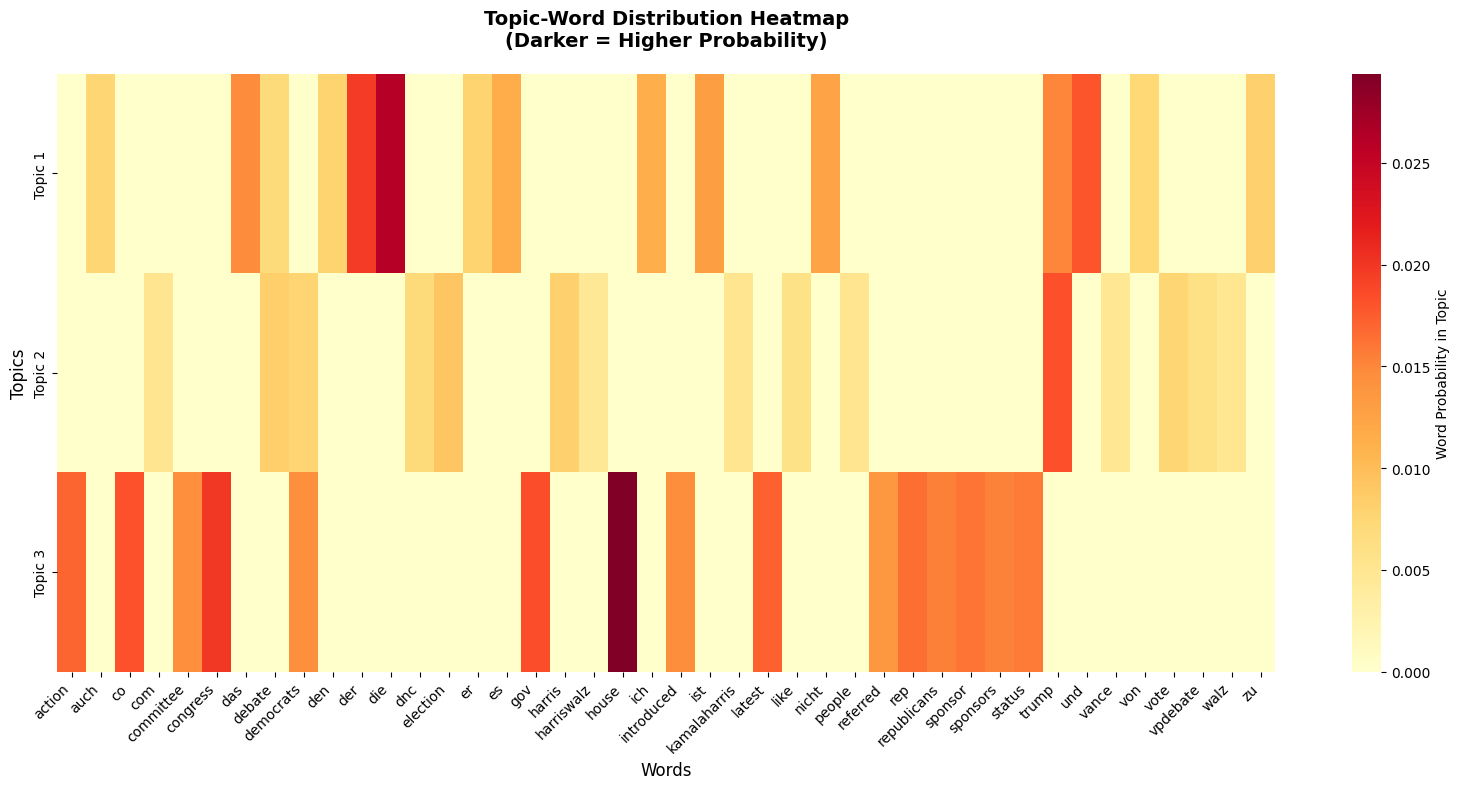

In [28]:
# Create a heatmap of topic-word distributions
top_n_words = 15  # Number of words to show per topic

# Collect top words and probabilities for each topic
topic_words = []
topic_probs = []
all_words = set()

for topic_id in range(num_topics):
    words_probs = lda_model.show_topic(topic_id, topn=top_n_words)
    words = [w for w, p in words_probs]
    probs = [p for w, p in words_probs]
    
    topic_words.append(words)
    topic_probs.append(probs)
    all_words.update(words)

# Create a matrix: rows = topics, columns = words
unique_words = sorted(all_words)
word_to_idx = {word: idx for idx, word in enumerate(unique_words)}

topic_word_matrix = np.zeros((num_topics, len(unique_words)))

for topic_id in range(num_topics):
    for word, prob in zip(topic_words[topic_id], topic_probs[topic_id]):
        topic_word_matrix[topic_id, word_to_idx[word]] = prob

# Visualize as heatmap
plt.figure(figsize=(16, 8))
sns.heatmap(
    topic_word_matrix,
    xticklabels=unique_words,
    yticklabels=[f'Topic {i+1}' for i in range(num_topics)],
    cmap='YlOrRd',
    annot=False,
    cbar_kws={'label': 'Word Probability in Topic'}
)

plt.title('Topic-Word Distribution Heatmap\n(Darker = Higher Probability)', 
         fontsize=14, fontweight='bold', pad=20)
plt.xlabel('Words', fontsize=12)
plt.ylabel('Topics', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

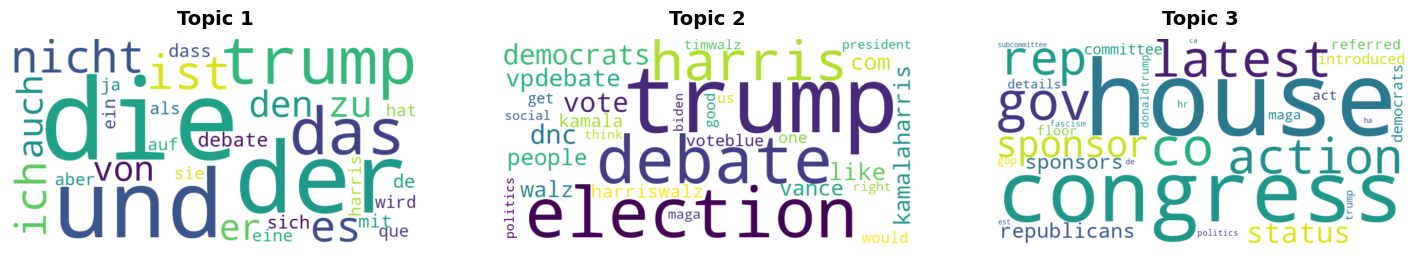

In [31]:
from wordcloud import WordCloud

# Create word clouds for each topic
fig, axes = plt.subplots(1, 3, figsize=(18, 12))
axes = axes.flatten()

for topic_id in range(num_topics):
    # Get word probabilities for this topic
    word_probs = dict(lda_model.show_topic(topic_id, topn=30))
    
    # Create word cloud
    wc = WordCloud(
        width=800,
        height=400,
        background_color='white',
        colormap='viridis',
        relative_scaling=0.5,
        min_font_size=10
    ).generate_from_frequencies(word_probs)
    
    # Plot
    ax = axes[topic_id]
    ax.imshow(wc, interpolation='bilinear')
    ax.set_title(f'Topic {topic_id + 1}', fontsize=14, fontweight='bold', pad=10)
    ax.axis('off')


In [36]:
len(corpus)

31909

In [41]:
# ─── Keep dates as a separate aligned Series ───
corpus_dates = df['date'].dt.date.reset_index(drop=True)

# Verify alignment
print(f"Corpus length: {len(corpus)}")
print(f"Dates length:  {len(corpus_dates)}")
print(corpus_dates.head())

Corpus length: 31909
Dates length:  31909
0    2024-11-04
1    2024-11-04
2    2024-11-04
3    2024-11-04
4    2024-11-04
Name: date, dtype: object


In [43]:
# ─── STEP 1: Get dominant topic per post ───
topic_ids, topic_probs = [], []

for bow in corpus:
    topics = lda_model.get_document_topics(bow)
    if topics:
        dominant = max(topics, key=lambda x: x[1])
        topic_ids.append(dominant[0])
        topic_probs.append(dominant[1])
    else:
        topic_ids.append(None)
        topic_probs.append(0.0)

# ─── STEP 2: Build post-level dataframe ───
post_df = pd.DataFrame({
    'date':       corpus_dates,
    'topic_id':   topic_ids,
    'topic_prob': topic_probs
})

# ─── STEP 3: Most prominent topic per day ───
dominant_per_day = (
    post_df.groupby(['date', 'topic_id'])
    .size()
    .reset_index(name='post_count')
    .sort_values(['date', 'post_count'], ascending=[True, False])
    .groupby('date')
    .first()
    .reset_index()
)

# ─── STEP 4: Add keyword labels ───
def topic_label(topic_id, n_words=5):
    words = lda_model.show_topic(int(topic_id), topn=n_words)
    return ' | '.join([w for w, _ in words])

dominant_per_day['topic_keywords'] = dominant_per_day['topic_id'].apply(topic_label)

print(dominant_per_day[['date', 'topic_id', 'post_count', 'topic_keywords']])

           date  topic_id  post_count  \
0    2024-07-05         1          36   
1    2024-07-06         1          16   
2    2024-07-07         1          22   
3    2024-07-08         1          20   
4    2024-07-09         1          25   
..          ...       ...         ...   
118  2024-10-31         1         645   
119  2024-11-01         1         634   
120  2024-11-02         1         617   
121  2024-11-03         1         789   
122  2024-11-04         1        1074   

                                     topic_keywords  
0    trump | election | debate | harris | democrats  
1    trump | election | debate | harris | democrats  
2    trump | election | debate | harris | democrats  
3    trump | election | debate | harris | democrats  
4    trump | election | debate | harris | democrats  
..                                              ...  
118  trump | election | debate | harris | democrats  
119  trump | election | debate | harris | democrats  
120  trump | election

In [44]:
# ─── Document distribution across topics ───
topic_counts = post_df['topic_id'].value_counts().sort_index()
total = len(post_df)

print("Document distribution across topics:\n")
print(f"{'Topic':<12} {'Count':<12} {'Percentage'}")
print("-" * 37)

for topic_id, count in topic_counts.items():
    pct = (count / total) * 100
    keywords = topic_label(topic_id)
    print(f"Topic {int(topic_id)+1:<6} {count:<12} {pct:.1f}%   [{keywords}]")

print("-" * 37)
print(f"\nTotal: {total} documents")


Document distribution across topics:

Topic        Count        Percentage
-------------------------------------
Topic 1      3207         10.1%   [die | der | und | trump | das]
Topic 2      25110        78.7%   [trump | election | debate | harris | democrats]
Topic 3      3592         11.3%   [house | congress | gov | co | latest]
-------------------------------------

Total: 31909 documents


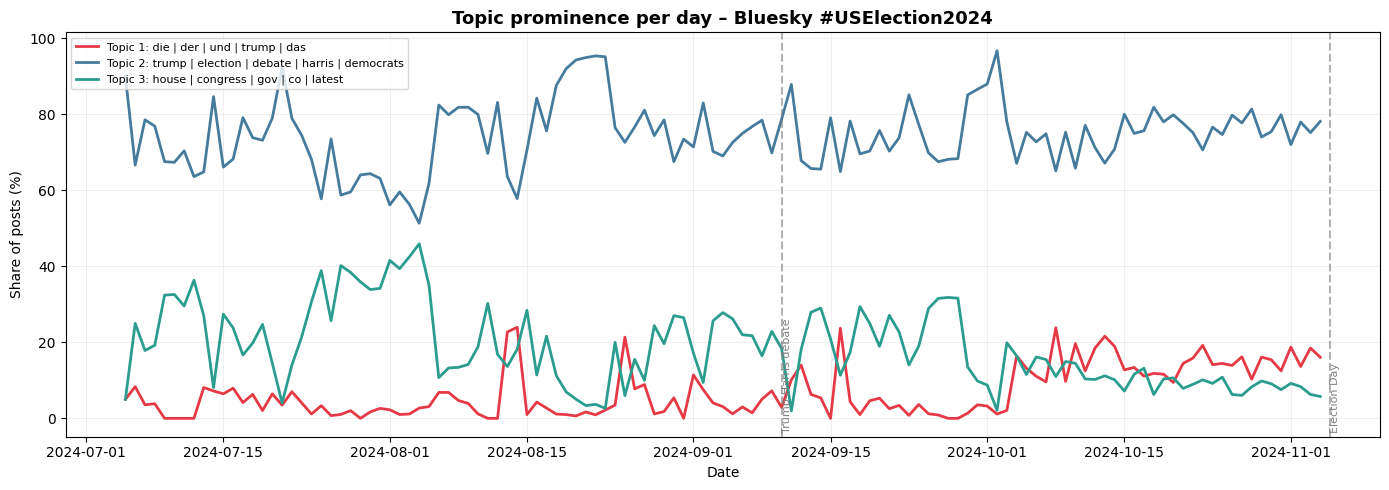

In [45]:
# ─── STEP 5: Compute topic share per day (% of posts per topic per day) ───
daily_topic_counts = (
    post_df.groupby(['date', 'topic_id'])
    .size()
    .reset_index(name='post_count')
)

daily_totals = post_df.groupby('date').size().reset_index(name='total')
daily_topic_counts = daily_topic_counts.merge(daily_totals, on='date')
daily_topic_counts['share'] = daily_topic_counts['post_count'] / daily_topic_counts['total'] * 100

# Pivot so each topic is a column
topic_share_pivot = daily_topic_counts.pivot(index='date', columns='topic_id', values='share').fillna(0)
topic_share_pivot.index = pd.to_datetime(topic_share_pivot.index)
topic_share_pivot = topic_share_pivot.sort_index()

# ─── STEP 6: Plot ───
colors = ['#e63946', '#457b9d', '#2a9d8f']
topic_labels = {i: topic_label(i) for i in range(num_topics)}

fig, ax = plt.subplots(figsize=(14, 5))

for topic_id in topic_share_pivot.columns:
    ax.plot(
        topic_share_pivot.index,
        topic_share_pivot[topic_id],
        label=f"Topic {int(topic_id)+1}: {topic_labels[topic_id]}",
        linewidth=2,
        color=colors[int(topic_id) % len(colors)]
    )

# ─── Key events ───
events = {
    '2024-09-10': 'Trump-Harris debate',
    '2024-11-05': 'Election Day',
}
for date_str, label in events.items():
    ax.axvline(pd.Timestamp(date_str), color='gray', linestyle='--', alpha=0.6)
    ax.text(pd.Timestamp(date_str), ax.get_ylim()[0] + 1, label,
            rotation=90, fontsize=8, color='gray', va='bottom')

ax.set_title("Topic prominence per day – Bluesky #USElection2024", fontsize=13, fontweight='bold')
ax.set_ylabel("Share of posts (%)")
ax.set_xlabel("Date")
ax.legend(fontsize=8, loc='upper left')
ax.grid(True, alpha=0.2)
plt.tight_layout()
plt.show()